In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import netCDF4 as nc
import xarray as xr

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import axis_ratio_from_Q, tangential_velocity


In [2]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, degree=3, tol=1e-8):
    x1,y1,u1,v1 = map(lambda a: np.asarray(a, float), (x1,y1,u1,v1))
    x2,y2,u2,v2 = map(lambda a: np.asarray(a, float), (x2,y2,u2,v2))

    m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
    x1,y1,u1,v1 = x1[m1], y1[m1], u1[m1], v1[m1]
    x2,y2,u2,v2 = x2[m2], y2[m2], u2[m2], v2[m2]

    nan2 = np.full((2, 2), np.nan)
    fail = (np.nan, np.nan, np.nan, nan2, np.nan)

    if x1.size < degree + 1 or x2.size < degree + 1:
        return fail

    # robust "common point" (floats): nearest pair within tol
    P1 = np.c_[x1, y1]
    P2 = np.c_[x2, y2]
    d2 = ((P1[:, None, :] - P2[None, :, :]) ** 2).sum(-1)
    i, j = np.unravel_index(np.argmin(d2), d2.shape)
    if d2[i, j] > tol**2:
        return fail
    center_x, center_y = P1[i]

    def root_near_mid(x, y):
        c = np.polyfit(x, y, degree)
        r = np.roots(c)
        r = r[np.isreal(r)].real
        if r.size == 0:
            return np.nan
        mid = x[x.size // 2]
        return r[np.argmin(np.abs(r - mid))]

    def tangent_fit(x, y, x0):
        c = np.polyfit(x, y, degree)
        slope = np.polyval(np.polyder(c), x0)
        intercept = np.polyval(c, x0) - slope * x0
        yhat = np.polyval(c, x)
        sst = np.sum((y - y.mean())**2)
        r2 = 1 - np.sum((y - yhat)**2)/sst if sst > 0 else 1.0
        return slope, intercept, r2

    xx = x1 - center_x
    yy = y2 - center_y

    rx = root_near_mid(xx, v1)
    ry = root_near_mid(yy, u2)
    if not (np.isfinite(rx) and np.isfinite(ry)):
        return fail

    A1, A0, r2A = tangent_fit(xx, u1, rx)
    B1, B0, r2B = tangent_fit(xx, v1, rx)
    C1, C0, r2C = tangent_fit(yy, u2, ry)
    D1, D0, r2D = tangent_fit(yy, v2, ry)

    alpha = A0 if r2A > r2C else C0
    beta  = B0 if r2B > r2D else D0
    gamma = A1 if r2A > r2D else -D1

    Aq11 = 0.5 * B1
    Aq22 = -0.5 * C1
    Aq12 = -0.5 * gamma

    denom = C1 * B1 + gamma**2
    if denom == 0 or not np.isfinite(denom):
        return fail

    xc = - (alpha * gamma + beta * C1) / denom + center_x
    yc =   (beta * gamma - alpha * B1) / denom + center_y
    w  = 2 * (Aq11 + Aq22)

    AQ = np.array([[Aq11, Aq12], [Aq12, Aq22]])
    det = AQ[0,0]*AQ[1,1] - AQ[0,1]*AQ[1,0]
    A = np.sign(Aq11) * np.sqrt(abs(det))
    Q = AQ / A if A != 0 else nan2

    return xc, yc, w, Q, A

def fit_psi_params(rho2, Qr, vt, A0=None, Rc0=None, plot=False, ax=None,
                   maxfev=10000, Rc_max=1e5, r2_flag=False,
                   rho_plot_max=None, n_curve=400):
    
    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]; Qr = Qr[m]; vt = vt[m]

    # v*_t = v_t * (rho/Qr)
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(rho2_, A, Rc):
        return 2.0 * A * np.sqrt(rho2_) * np.exp(-rho2_ / (Rc * Rc))

    # initial Rc0 from location of max |vt|
    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]
    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2.0), 1e-6)

    if A0 is None:
        denom = 2.0 * rho * np.exp(-rho2 / (Rc0 * Rc0))
        ok = np.abs(denom) > 0
        A0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0.0
    if not np.isfinite(A0):
        A0 = 0.0

    try:
        popt, _ = curve_fit(
            vt_model, rho2, vt, p0=[A0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        A_opt, Rc_opt = popt
    except Exception:
        A_opt, Rc_opt = A0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        A_opt, Rc_opt = A0, Rc0

    psi0_opt = -A_opt * Rc_opt**2

    vt_fit = vt_model(rho2, A_opt, Rc_opt)
    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    if plot:
        if ax is None:
            _, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = float(np.nanmax(rho)) if rho.size else Rc_opt

        r_grid = np.linspace(0.0, rho_plot_max, n_curve)
        vt_grid = vt_model(r_grid**2, A_opt, Rc_opt)

        core_mask = rho <= 30_000
        ax.scatter(rho[core_mask], np.abs(vt[core_mask]), s=20, marker='.', label='Core observed', color='m')
        ax.scatter(rho[~core_mask], np.abs(vt[~core_mask]), s=20, marker='.', label='Outer-core observed', color='g')
        ax.plot(r_grid, np.abs(vt_grid), lw=2, label='Fit', color='b')
        ax.axvline(Rc_opt/np.sqrt(2), ls='--', lw=2, label=r'$\rho_{\max}$', color='r')

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')
        ax.set_title(f'A={A_opt:.4g}, Rc={Rc_opt:.4g}, psi0={psi0_opt:.4g}, R²={r2:.2f}')
        ax.legend()

    return (Rc_opt, psi0_opt, A_opt, r2) if r2_flag else (Rc_opt, psi0_opt, A_opt)
    

In [3]:
def dopioe_pipeliner(nxc, nyc, ut, vt, X_new, Y_new, r=30000.0):
    nan = (np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan)

    x = np.asarray(X_new[:, 0], float)
    y = np.asarray(Y_new[0, :], float)

    dx = np.nanmedian(np.abs(np.diff(x)))
    dy = np.nanmedian(np.abs(np.diff(y)))
    cell = np.nanmax([dx, dy])
    if not np.isfinite(cell) or cell == 0:
        return nan

    margin = int(np.ceil(r / cell))

    ic = int(np.clip(np.searchsorted(x, nxc), 1, x.size-1))
    ic -= (nxc - x[ic-1] < x[ic] - nxc)
    jc = int(np.clip(np.searchsorted(y, nyc), 1, y.size-1))
    jc -= (nyc - y[jc-1] < y[jc] - nyc)

    if ic < margin or ic >= x.size - margin or jc < margin or jc >= y.size - margin:
        return nan

    # x-transect (y = y[jc])
    i0 = np.searchsorted(x, nxc - r, side="left")
    i1 = np.searchsorted(x, nxc + r, side="right")
    x1 = x[i0:i1]
    y1 = np.full(x1.size, y[jc])
    u1 = ut[i0:i1, jc]
    v1 = vt[i0:i1, jc]

    # y-transect (x = x[ic])
    j0 = np.searchsorted(y, nyc - r, side="left")
    j1 = np.searchsorted(y, nyc + r, side="right")
    y2 = y[j0:j1]
    x2 = np.full(y2.size, x[ic])
    u2 = ut[ic, j0:j1]
    v2 = vt[ic, j0:j1]

    return x1, y1, u1, v1, x2, y2, u2, v2
    

### Numerical Data

In [4]:
ssh_path = '/srv/scratch/z5297792/ESP_Paper_Data/sat_data_copernicus_CCE_2023_1D.nc'
ds_nc = nc.Dataset(ssh_path)

lon, lat = ds_nc['longitude'][:], ds_nc['latitude'][:]
u = np.squeeze(ds_nc['uo'][:]); v = np.squeeze(ds_nc['vo'][:])
# u, v = np.transpose(u, (2,1,0)), np.transpose(v, (2,1,0))  # (time, lat, lon)
t = pd.Timestamp("1950-01-01") + pd.to_timedelta(ds_nc['time'][:], "h")
u, v = np.where(np.abs(u) < 100, u, np.nan), np.where(np.abs(v) < 100, v, np.nan)
lon2d, lat2d = np.meshgrid(lon, lat, indexing="xy")
theta_mean, phi_mean = 154.3, -37.9
x = (lon2d-theta_mean)*111000*np.cos(np.deg2rad(phi_mean))
y = (lat2d-phi_mean)*111000
ds_cop = xr.Dataset(
    {"u": (("time","lat","lon"), u),
     "v": (("time","lat","lon"), v)},
    coords={"time": t, "lat": lat, "lon": lon,
            "x": (("lat","lon"), x),
            "y": (("lat","lon"), y)}
)
ds_cop["land_mask"] = np.isnan(ds_cop.u.isel(time=0)) & np.isnan(ds_cop.v.isel(time=0))
# # Time slice
ds_cop = ds_cop.sel(time=ds_cop.time <= np.datetime64('2024-01-27T00:00:00.000000000'))

ds_cop


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 101, lat: 97, lon: 109)
Coordinates:
  * time       (time) datetime64[ns] 808B 2023-10-19 ... 2024-01-27
  * lat        (lat) float32 388B -42.0 -41.92 -41.83 ... -34.17 -34.08 -34.0
  * lon        (lon) float32 436B 149.0 149.1 149.2 149.2 ... 157.8 157.9 158.0
    x          (lat, lon) float64 85kB -4.642e+05 -4.569e+05 ... 3.241e+05
    y          (lat, lon) float64 85kB -4.551e+05 -4.551e+05 ... 4.329e+05
Data variables:
    u          (time, lat, lon) float32 4MB -0.284 -0.3366 ... 0.3254 0.346
    v          (time, lat, lon) float32 4MB -0.2342 -0.1941 ... -0.1586 -0.1242
    land_mask  (lat, lon) bool 11kB False False False ... False False False

In [5]:
xc_pre, yc_pre = 0.0, 0.0
rows = []
xyuv_rows = []

X = ds_cop.x.values
Y = ds_cop.y.values

for time in ds_cop.time.values:
    ut = ds_cop.u.sel(time=time).values
    vt = ds_cop.v.sel(time=time).values

    x1,y1,u1,v1,x2,y2,u2,v2 = dopioe_pipeliner(xc_pre, yc_pre, ut.T, vt.T, X.T, Y.T, r=50_000)
    xc, yc, w, Q, A = doppio(x1,y1,u1,v1, x2,y2,u2,v2)

    ok = (np.isfinite(xc) and np.isfinite(yc) and
          (np.hypot(xc-xc_pre, yc-yc_pre) < 100_000) and (w < 0))

    if not ok:
        break

    rows.append(dict(xc=xc, yc=yc, w=w, Q=Q, A=A, time=time))
    xc_pre, yc_pre = xc, yc

    xi = np.concatenate([x1, x2])
    yi = np.concatenate([y1, y2])
    ui = np.concatenate([u1, u2])
    vi = np.concatenate([v1, v2])

    xyuv_rows.append(pd.DataFrame({
        "time": time,
        "core": "inner",
        "xi": xi, "yi": yi, "ui": ui, "vi": vi
    }))

df_res = pd.DataFrame(rows, columns=["xc","yc","w","Q","A","time"])
df_res["alpha"] = [axis_ratio_from_Q(Q) for Q in df_res["Q"].to_list()]

df_xyuv = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_res


,xc,yc,w,Q,A,time,alpha
0,-5800.573587,-629.255116,-0.000040,"[[1.0257835485237774, -0.06582692058402737], [...",-0.000010,2023-10-19 00:00:00,1.072281
1,-3945.601076,1292.916423,-0.000040,"[[0.9469093678079442, -0.10253673150655421], [...",-0.000010,2023-10-19 23:56:15,1.125907
2,-7305.893964,-5404.284853,-0.000041,"[[0.9260127534658863, -0.1298871082567435], [-...",-0.000010,2023-10-21 00:00:00,1.167872
3,-3349.589416,-3906.695508,-0.000042,"[[0.894999634843592, -0.11703436509009026], [-...",-0.000010,2023-10-22 00:00:00,1.180584
4,-1579.605006,-4762.774618,-0.000042,"[[0.8243945558653097, -0.05360848246487654], [...",-0.000010,2023-10-22 23:56:15,1.223695
...,...,...,...,...,...,...,...
96,-255182.574475,165447.045281,-0.000026,"[[1.1832253500327596, 0.054642610899420865], [...",-0.000006,2024-01-23 00:00:00,1.191899
97,-254876.193369,161939.318610,-0.000018,"[[1.5014342293367229, -0.21974496366399002], [...",-0.000004,2024-01-24 00:00:00,1.557620
98,-267792.208065,155385.527815,-0.000018,"[[1.3193080147083844, -0.3941161158350322], [-...",-0.000004,2024-01-25 00:00:00,1.549750
99,-256896.841604,170474.212901,-0.000018,"[[1.3336995708020167, -0.6755423989074428], [-...",-0.000004,2024-01-26 00:00:00,1.899104


(np.float64(-281178.7117610954),
 np.float64(13324.369551218098),
 np.float64(-17739.926304120472),
 np.float64(191835.08255346163))

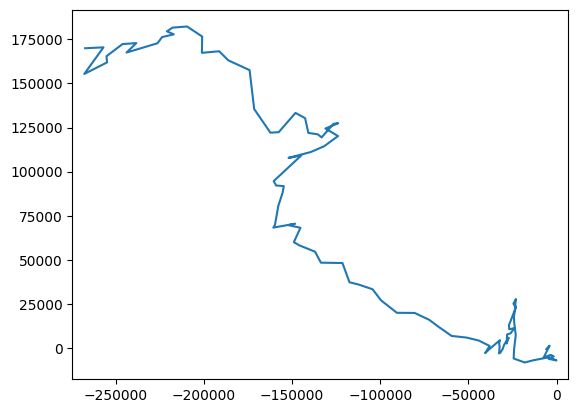

In [6]:
plt.plot(df_res.xc, df_res.yc)
plt.axis('equal')


,xc,yc,w,Q,A,time,alpha,Rc,psi0,Omega
0,-5800.573587,-629.255116,-0.000036,"[[1.0257835485237774, -0.06582692058402737], [...",-0.000009,2023-10-19 00:00:00,1.072281,83924.092990,63147.913459,-0.000036
1,-3945.601076,1292.916423,-0.000036,"[[0.9469093678079442, -0.10253673150655421], [...",-0.000009,2023-10-19 23:56:15,1.125907,83770.298112,62793.184319,-0.000036
2,-7305.893964,-5404.284853,-0.000036,"[[0.9260127534658863, -0.1298871082567435], [-...",-0.000009,2023-10-21 00:00:00,1.167872,84556.751451,63048.237624,-0.000035
3,-3349.589416,-3906.695508,-0.000037,"[[0.894999634843592, -0.11703436509009026], [-...",-0.000009,2023-10-22 00:00:00,1.180584,83691.843449,63535.302678,-0.000036
4,-1579.605006,-4762.774618,-0.000037,"[[0.8243945558653097, -0.05360848246487654], [...",-0.000009,2023-10-22 23:56:15,1.223695,82928.702339,62673.679271,-0.000036
...,...,...,...,...,...,...,...,...,...,...
96,-255182.574475,165447.045281,-0.000034,"[[1.1832253500327596, 0.054642610899420865], [...",-0.000008,2024-01-23 00:00:00,1.191899,63754.226000,33573.478176,-0.000033
97,-254876.193369,161939.318610,-0.000033,"[[1.5014342293367229, -0.21974496366399002], [...",-0.000007,2024-01-24 00:00:00,1.557620,65761.744484,32374.757321,-0.000030
98,-267792.208065,155385.527815,-0.000029,"[[1.3193080147083844, -0.3941161158350322], [-...",-0.000007,2024-01-25 00:00:00,1.549750,69617.456921,32058.816960,-0.000026
99,-256896.841604,170474.212901,-0.000022,"[[1.3336995708020167, -0.6755423989074428], [-...",-0.000004,2024-01-26 00:00:00,1.899104,85873.135309,33156.035186,-0.000018


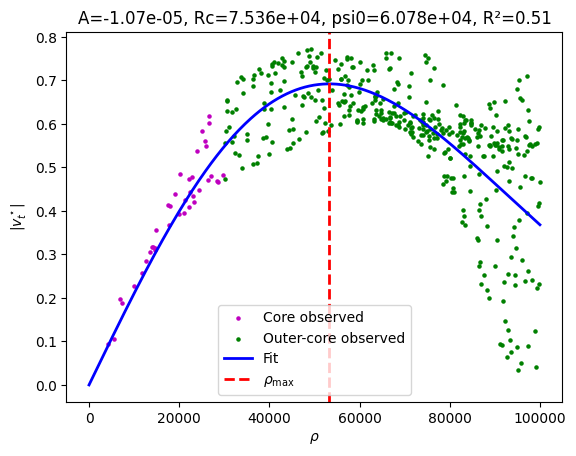

In [7]:
rho_outer = 100_000.0

xi0 = ds_cop.x.values.ravel()
yi0 = ds_cop.y.values.ravel()

Rc_opts, psi0_opts, A_opts = [], [], []
xyuv_rows = []

for k, data in df_res.iterrows():
    time = data.time

    ui0 = ds_cop.u.sel(time=time).values.ravel()
    vi0 = ds_cop.v.sel(time=time).values.ravel()

    xc, yc = float(data.xc), float(data.yc)
    Q = np.asarray(data.Q)
    A = float(data.A)
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

    dx = xi0 - xc
    dy = yi0 - yc
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy

    outer = rho2 <= rho_outer**2
    xi_o, yi_o = xi0[outer], yi0[outer]
    ui_o, vi_o = ui0[outer], vi0[outer]
    dx_o, dy_o, rho2_o = dx[outer], dy[outer], rho2[outer]

    xyuv_rows.append(pd.DataFrame({
        "time": time, "core": "outer",
        "xi": xi_o, "yi": yi_o, "ui": ui_o, "vi": vi_o
    }))

    vt_o = tangential_velocity(xi_o, yi_o, ui_o, vi_o, xc, yc, Q)
    Qr_o = np.sqrt((q11*dx_o + q12*dy_o)**2 + (q12*dx_o + q22*dy_o)**2)

    sign_mask = (vt_o <= 0) if (A < 0) else (vt_o >= 0)
    rho2_f, Qr_f, vt_f = rho2_o[sign_mask], Qr_o[sign_mask], vt_o[sign_mask]

    Rc_opt, psi0_opt, A_opt = fit_psi_params(rho2_f, Qr_f, vt_f, A0=A, plot=(k == 10))
    Rc_opts.append(Rc_opt); psi0_opts.append(psi0_opt); A_opts.append(A_opt)

df_xyuv_o = pd.concat(xyuv_rows, ignore_index=True) if xyuv_rows else pd.DataFrame(
    columns=["time","core","xi","yi","ui","vi"]
)

df_xyuv = pd.concat([df_xyuv, df_xyuv_o], ignore_index=True)
df_xyuv = (
    df_xyuv
    .sort_values(by="core", key=lambda s: s.eq("outer"))  # keep inner first
    .drop_duplicates(subset=["time", "xi", "yi", "ui", "vi"], keep="first")
    .reset_index(drop=True)
)

df_res["Rc"] = Rc_opts
df_res["psi0"] = psi0_opts
df_res["A"] = A_opts
df_res["w"] = [2*A*(Q[0,0] + Q[1,1]) for (A,Q) in zip(df_res.A, df_res.Q)]
df_res["Omega"] = 4*df_res.A
df_res


In [8]:
# Find r2
def model_uv_at_xy(xi, yi, xc, yc, Q, A, Rc):
    dx = xi - xc
    dy = yi - yc
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
    rho2 = q11*dx*dx + 2*q12*dx*dy + q22*dy*dy
    fac = A * np.exp(-rho2 / (Rc*Rc))
    uhat = -fac * (2*q12*dx + 2*q22*dy)
    vhat =  fac * (2*q11*dx + 2*q12*dy)
    return uhat, vhat
    
def vector_r2(u, v, uhat, vhat):
    m = np.isfinite(u) & np.isfinite(v) & np.isfinite(uhat) & np.isfinite(vhat)
    if not np.any(m):
        return np.nan
    u, v, uhat, vhat = u[m], v[m], uhat[m], vhat[m]
    err2 = (uhat - u)**2 + (vhat - v)**2
    u0, v0 = np.mean(u), np.mean(v)
    tot2 = (u - u0)**2 + (v - v0)**2
    return 1 - np.sum(err2)/np.sum(tot2) if np.sum(tot2) > 0 else np.nan

r2_vals = []
for _, row in df_res.iterrows():
    df = df_xyuv[df_xyuv.time == row.time]
    xi = df.xi.to_numpy(float)
    yi = df.yi.to_numpy(float)
    u  = df.ui.to_numpy(float)
    v  = df.vi.to_numpy(float)
    uhat, vhat = model_uv_at_xy(xi, yi, row.xc, row.yc, np.asarray(row.Q), row.A, row.Rc)
    r2_vals.append(vector_r2(u, v, uhat, vhat))

df_res["r2"] = r2_vals


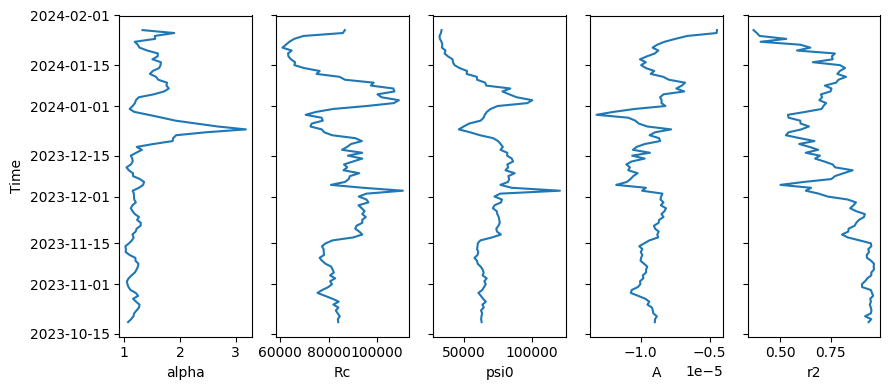

In [9]:
fig, axs = plt.subplots(1, 5, sharey=True, figsize=(9,4))

cols = ["alpha", "Rc", "psi0", "A", "r2"]

for ax, c in zip(axs, cols):
    ax.plot(df_res[c], df_res.time)
    ax.set_xlabel(c)

axs[0].set_ylabel("Time")

plt.tight_layout()


In [10]:
X = ds_cop.x.values
Y = ds_cop.y.values
nt = len(df_res)

U = np.empty((nt, X.shape[0], X.shape[1]))
V = np.empty((nt, X.shape[0], X.shape[1]))

for k in range(nt):
    data = df_res.iloc[k]

    dx = X - data.xc
    dy = Y - data.yc

    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]

    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    fac = data.A * np.exp(-rho2 / data.Rc**2)

    U[k] = -fac * (2*q12*dx + 2*q22*dy)
    V[k] =  fac * (2*q11*dx + 2*q12*dy)

mask = ds_cop.land_mask.values[None, :, :]   # (1, lat, lon)
U = np.where(mask, np.nan, U)
V = np.where(mask, np.nan, V)

ds_model = xr.Dataset(
    data_vars=dict(
        u=(("time","lat","lon"), U),
        v=(("time","lat","lon"), V),
    ),
    coords=dict(
        time=df_res.time.values,
        lat=ds_cop.lat.values,
        lon=ds_cop.lon.values,
        x=(("lat","lon"), X),
        y=(("lat","lon"), Y),
    ),
)

In [11]:
def plot__model(df_res, ds_cop, ds_model, df_xyuv, time=None, spac=1, scale=20,
                      xlim=(-410, 200), ylim=(-160, 260), out_thresh=False, plot_data=False):

    if time is None:
        time = ds_model.time.values[0]

    sat = ds_cop.sel(time=time, method="nearest")
    mod = ds_model.sel(time=time, method="nearest")
    data = df_res[df_res.time == time].iloc[0]

    X = sat.x.values / 1e3
    Y = sat.y.values / 1e3

    us, vs = sat.u.values, sat.v.values
    um, vm = mod.u.values, mod.v.values

    sp_s = np.hypot(us, vs)
    sp_m = np.hypot(um, vm)

    dx, dy = sat.x.values - data.xc, sat.y.values - data.yc
    q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

    # ROI mask in km-space
    roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
    sp_s_roi = np.where(roi, sp_s, np.nan)
    sp_m_roi = np.where(roi, sp_m, np.nan)
    roi_quiv = roi & (rho2 >= 100_000**2)

    # combine the two fields to determine colour scale
    vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
    vmin, vmax = np.nanmin(vals), np.nanmax(vals)
    levels = np.arange(0, vmax+.05, .05)

    X_rho, Y_rho = np.meshgrid(np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100), np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100))
    dx = X_rho - data.xc
    dy = Y_rho - data.yc
    rho2 = data.Q[0,0]*dx**2 + 2*data.Q[1,0]*dx*dy + data.Q[1,1]*dy**2

    fig, axs = plt.subplots(1, 2, figsize=(15,7), sharex=True, sharey=True, constrained_layout=True)

    # ---- Satellite ----
    h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")

    axs[0].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
                  np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.4)

    axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
    axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2) 
    if out_thresh:
        axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[100_000**2], colors="r", linewidths=2, linestyles='--')
    axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)
    if plot_data:
        df = df_xyuv.copy()
        df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='outer')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color='g', label='Outer-core data')
        df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='inner')]
        axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color='m', label='Core data')
    axs[0].set_title("Numerical Model")
    axs[0].set_aspect("equal"); axs[0].legend(loc='lower left')

    # ---- Model ----
    h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
    axs[1].quiver(X[::spac,::spac], Y[::spac,::spac],
                  np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
                  np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
                  scale=scale, width=.0015, alpha=.5)
    axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label='Eddy center')
    axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[(data.Rc**2)/2], colors="r", linewidths=2)
    axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color='r', label='Max tangential\nvelocity')
    axs[1].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5, label='Center path')
    if out_thresh:
        axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[100_000**2], colors="r", linewidths=2, linestyles='--')
    # if plot_data:
    #     df = df_xyuv.copy()
    #     df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='outer')]
    #     axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='g')
    #     df = df_xyuv[(df_xyuv.time==time)&(df_xyuv.core=='inner')]
    #     axs[1].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.002, color='m')
    axs[1].set_title("Model - DOPPIO with Numerical Data")
    axs[1].set_aspect("equal"); axs[1].legend(loc='lower left')

    gap = 20
    for ax in axs:
        ax.set_xlim(xlim[0]+gap, xlim[1]-gap)
        ax.set_ylim(ylim[0]+gap, ylim[1]-gap)
        ax.set_xlabel("x (km)")
    axs[0].set_ylabel("y (km)")

    axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
    axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

    fig.colorbar(h1, ax=axs, label="Current speed (ms$^{-1}$)", fraction=0.0165, pad=0.02)
    # fig.suptitle(f"time ≈ {np.datetime_as_string(time, unit='m')}")
    print(time)
    plt.show()
    

2023-10-22T00:00:00.000000000


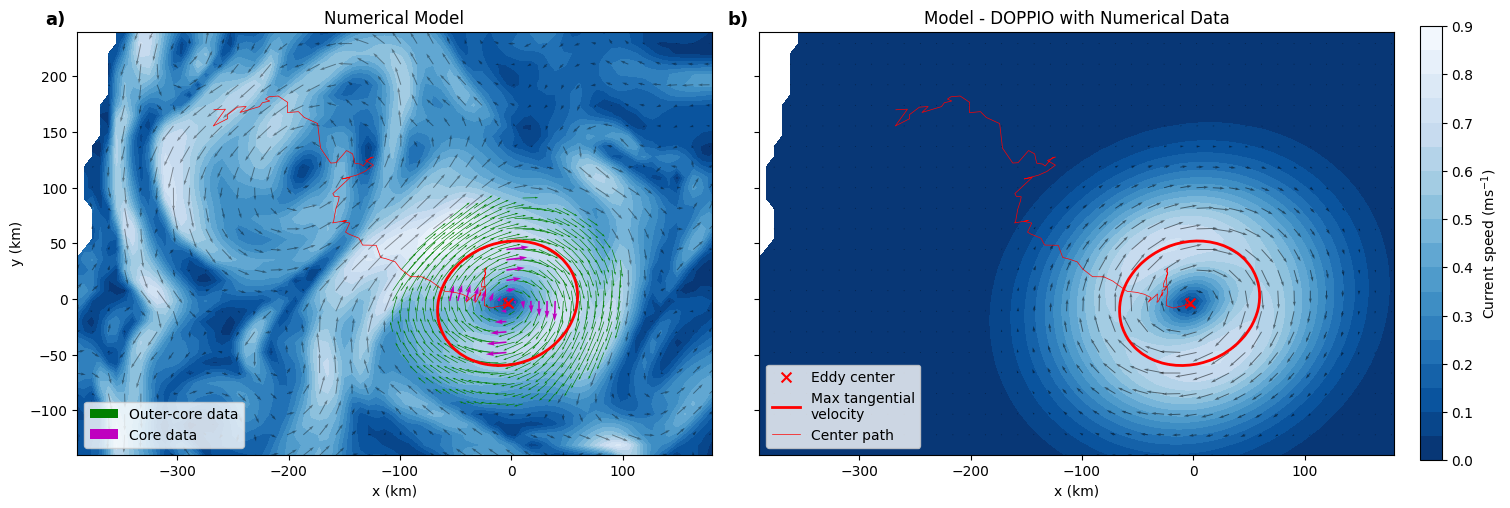

In [12]:
plot__model(df_res, ds_cop, ds_model, df_xyuv, time=df_res.time.values[3], spac=2, out_thresh=False, plot_data=True)


In [13]:
df_paper = df_res.copy()
df_paper = df_paper.drop(columns='A')
df_paper.loc[np.arange(0, 100, 10)]


,xc,yc,w,Q,time,alpha,Rc,psi0,Omega,r2
0,-5800.573587,-629.255116,-0.000036,"[[1.0257835485237774, -0.06582692058402737], [...",2023-10-19 00:00:00,1.072281,83924.092990,63147.913459,-0.000036,0.939076
10,-24303.003310,-5962.593294,-0.000044,"[[1.1299496813576198, 0.15581838205751974], [0...",2023-10-29 00:00:00,1.209955,75358.255892,60779.153090,-0.000043,0.955880
20,-24180.196720,20162.034461,-0.000040,"[[1.2458129876849724, -0.0706840454780243], [-...",2023-11-08 00:00:00,1.256911,78646.007975,60258.395153,-0.000039,0.965686
30,-30549.916314,-610.917081,-0.000035,"[[1.147315254846027, -0.026816798774608398], [...",2023-11-18 00:00:00,1.149905,93848.380736,77385.258554,-0.000035,0.806901
40,-50897.797513,5886.483448,-0.000034,"[[1.1318926375389338, -0.06946851388181274], [...",2023-11-28 00:00:00,1.150274,92280.961426,72651.706367,-0.000034,0.864095
50,-117401.390801,37265.413834,-0.000043,"[[1.0687557214864998, -0.13805503075185124], [...",2023-12-08 00:00:00,1.160728,88734.997172,82859.062047,-0.000042,0.772138
60,-159668.941507,69751.204220,-0.000042,"[[1.1884943144559839, -0.11909296605603428], [...",2023-12-17 23:56:15,1.226502,87549.338046,78834.402631,-0.000041,0.645602
70,-123899.986679,120170.983881,-0.000050,"[[0.6133029962713871, -0.14323562639270807], [...",2023-12-28 00:00:00,1.683145,77049.637929,64601.824747,-0.000044,0.541652
80,-162257.937285,122090.675688,-0.000035,"[[1.7681823117339088, -0.20242712125377255], [...",2024-01-07 00:00:00,1.801957,106672.149669,84333.571550,-0.000030,0.754868
90,-217028.162627,177832.191741,-0.000044,"[[0.666858458184169, -0.055734455030787326], [...",2024-01-17 00:00:00,1.507920,64441.304935,41694.867941,-0.000040,0.761108


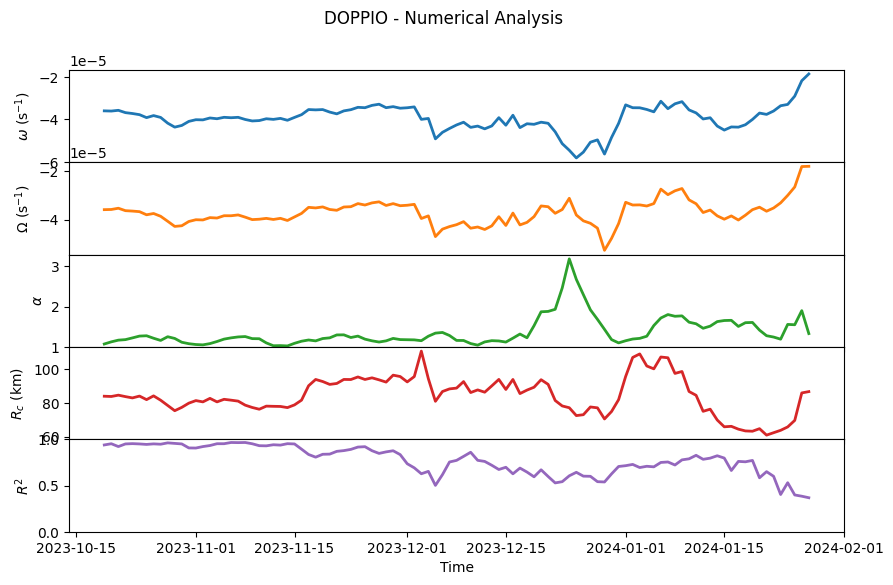

In [14]:
clrs = plt.colormaps['tab10']
fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
lw = 2

axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')

axs[1].plot(df_res.time, df_res.Omega, color=clrs(1), lw=lw)
axs[1].set_ylabel(r'$\Omega$ (s$^{-1}$)')

axs[2].plot(df_res.time, df_res.alpha, color=clrs(2), lw=lw)
axs[2].set_ylabel(r'$\alpha$')
axs[2].set_ylim(1, None)

axs[3].plot(df_res.time, df_res.Rc/1e3, color=clrs(3), lw=lw)
axs[3].set_ylabel(r'$R_c$ (km)')

axs[4].plot(df_res.time, df_res.r2, color=clrs(4), lw=lw)
axs[4].set_ylabel(r'$R^2$')
axs[4].set_xlabel('Time')
axs[4].set_ylim(0,1)

fig.suptitle("DOPPIO - Numerical Analysis")
fig.subplots_adjust(hspace=0)


In [15]:
# clrs = plt.colormaps['tab10']
# fig, axs = plt.subplots(5, 1, figsize=(10,6), sharex=True)
# lw = 2

# axs[0].plot(df_res.time, df_res.w, color=clrs(0), lw=lw)
# axs[0].set_ylabel(r'$\omega$ (s$^{-1}$)')
# axs[1].plot(df_res.time, df_res.alpha, color=clrs(1), lw=lw)
# axs[1].set_ylabel(r'$\alpha$'); axs[1].set_ylim(1,None)
# axs[2].plot(df_res.time, df_res.Rc/1e3, color=clrs(2), lw=lw)
# axs[2].set_ylabel(r'$R_c$ (km)')
# axs[3].plot(df_res.time, df_res.Omega, color=clrs(3), lw=lw)
# axs[3].set_ylabel(r'$\Omega$ (s$^{-1}$)')
# axs[4].plot(df_res.time, df_res.r2, color=clrs(4), lw=lw)
# axs[4].set_ylabel(r'$R^2$')
# axs[4].set_xlabel('Time'); axs[4].set_ylim(0,1)

# fig.suptitle(f"DOPPIO - Numerical Analysis")

# fig.subplots_adjust(hspace=0)


### Animation

In [16]:
# import os

# def save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_drifter_animation",
#     spac=2, scale=20, xlim=(-410, 200), ylim=(-160, 260),
#     out_thresh=False, plot_data=False, vmax=1.2
# ):
#     os.makedirs(outdir, exist_ok=True)

#     frame_paths = []

#     for t_idx in range(len(df_res)):
#         data = df_res.iloc[t_idx]
#         time = data.time

#         sat = ds_cop.sel(time=time, method="nearest")
#         mod = ds_model.sel(time=time, method="nearest")

#         X = sat.x.values / 1e3
#         Y = sat.y.values / 1e3

#         us, vs = sat.u.values, sat.v.values
#         um, vm = mod.u.values, mod.v.values

#         sp_s = np.hypot(us, vs)
#         sp_m = np.hypot(um, vm)

#         dx = sat.x.values - data.xc
#         dy = sat.y.values - data.yc
#         q11, q12, q22 = data.Q[0,0], data.Q[0,1], data.Q[1,1]
#         rho2_grid = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         roi = (X >= xlim[0]) & (X <= xlim[1]) & (Y >= ylim[0]) & (Y <= ylim[1])
#         sp_s_roi = np.where(roi, sp_s, np.nan)
#         sp_m_roi = np.where(roi, sp_m, np.nan)
#         roi_quiv = roi & (rho2_grid >= 100_000**2)

#         vals = np.concatenate([sp_s_roi[roi], sp_m_roi[roi]])
#         # vmax = np.nanmax(vals)
#         levels = np.arange(0, vmax + 0.05, 0.05)

#         x_rho = np.linspace(xlim[0]*1e3, xlim[1]*1e3, 100)
#         y_rho = np.linspace(ylim[0]*1e3, ylim[1]*1e3, 100)
#         X_rho, Y_rho = np.meshgrid(x_rho, y_rho)

#         dx = X_rho - data.xc
#         dy = Y_rho - data.yc
#         rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2

#         fig, axs = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)

#         # ---- Numerical model ----
#         h0 = axs[0].contourf(X, Y, sp_s_roi, levels=levels, cmap="Blues_r")
#         axs[0].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi_quiv[::spac,::spac], us[::spac,::spac], np.nan),
#             np.where(roi_quiv[::spac,::spac], vs[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.4
#         )
#         axs[0].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50)
#         axs[0].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[0].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5)

#         if plot_data:
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "outer")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.001, color="g", label="Outer-core data")
#             df = df_xyuv[(df_xyuv.time == time) & (df_xyuv.core == "inner")]
#             axs[0].quiver(df.xi/1e3, df.yi/1e3, df.ui, df.vi, scale=scale, width=.0025, color="m", label="Core data")

#         axs[0].set_title("Numerical Model")
#         axs[0].set_aspect("equal")
#         axs[0].legend(loc="lower left")

#         # ---- Fitted model ----
#         h1 = axs[1].contourf(X, Y, sp_m_roi, levels=levels, cmap="Blues_r")
#         axs[1].quiver(
#             X[::spac,::spac], Y[::spac,::spac],
#             np.where(roi[::spac,::spac], um[::spac,::spac], np.nan),
#             np.where(roi[::spac,::spac], vm[::spac,::spac], np.nan),
#             scale=scale, width=.0015, alpha=.5
#         )
#         axs[1].scatter(data.xc/1e3, data.yc/1e3, marker="x", color="r", s=50, label="Eddy center")
#         axs[1].contour(X_rho/1e3, Y_rho/1e3, rho2, levels=[data.Rc**2/2], colors="r", linewidths=2, linestyles="--")
#         axs[1].plot([np.nan, np.nan], [np.nan, np.nan], lw=2, color="r", label="Max tangential\nvelocity", ls="--")
#         axs[1].plot(df_res.xc/1e3, df_res.yc/1e3, color="r", lw=.5, label="Center path")
#         axs[1].set_title("Model - DOPPIO with Numerical Data")
#         axs[1].set_aspect("equal")
#         axs[1].legend(loc="lower left")

#         gap = 20
#         for ax in axs:
#             ax.set_xlim(xlim[0] + gap, xlim[1] - gap)
#             ax.set_ylim(ylim[0] + gap, ylim[1] - gap)
#             ax.set_xlabel("x (km)")
#         axs[0].set_ylabel("y (km)")

#         axs[0].text(-0.05, 1.05, "a)", transform=axs[0].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")
#         axs[1].text(-0.05, 1.05, "b)", transform=axs[1].transAxes, fontsize=13, fontweight="bold", va="top", ha="left")

#         fig.colorbar(h1, ax=axs, label="Current speed (m s$^{-1}$)", fraction=0.0165, pad=0.02)
#         fig.suptitle(f"{time}")

#         frame_path = os.path.join(outdir, f"frame_{t_idx:03d}.png")
#         fig.savefig(frame_path, dpi=250, bbox_inches="tight")
#         plt.close(fig)
#         frame_paths.append(frame_path)

#     return 
    

In [17]:
# save_model_frames(
#     df_res, ds_cop, ds_model, df_xyuv,
#     outdir="/srv/scratch/z5297792/solo_doppio_latte_paper/doppio_num_animation",
#     out_thresh=False, plot_data=True
# )
